<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/sc/single.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S-Curve Model for Monthly New Well Count
To model the gradual increase in new well count from an initial 500 wells/month to a stabilized 650 wells/month, while achieving a total of 7000 wells over the next 12 months, I will use an S-curve based on the error function (erf).

The erf function is ideal for this as it provides a smooth, sigmoidal transition from a lower bound to an upper bound. The general form of the S-curve for the monthly rate will be:

N(t) = InitialRate + (StabilizedRate - InitialRate) * 0.5 * (1 + erf((t - t_mid) / (sigma * sqrt(2))))

Where:

N(t): Monthly new well count at month t.
InitialRate: The starting monthly well count (500).
StabilizedRate: The eventual monthly well count (650).
t_mid: The midpoint of the S-curve, where the growth is steepest.
sigma: Controls the spread or steepness of the S-curve. A smaller sigma means a steeper curve.
I will use numerical optimization to find the values of t_mid and sigma that satisfy the condition of 7000 total wells over 12 months. The initial conditions (500 wells/month at t=0) and stabilization (650 wells/month) are inherently handled by the model's structure.

In [10]:
import numpy as np
from scipy.special import erf
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Define the S-curve function for the monthly rate
def s_curve_rate(t, t_mid, sigma, initial_rate, final_rate):
    """
    S-curve model for monthly new well count rate using the error function.
    Ranges from initial_rate to final_rate.
    """
    if sigma <= 0: # Ensure sigma is positive for a valid curve
        return np.full_like(t, 1e9) # Return a large penalty value

    # The erf function ranges from -1 to 1.
    # 0.5 * (1 + erf(x)) will range from 0 to 1.
    growth_factor = 0.5 * (1 + erf((t - t_mid) / (sigma * np.sqrt(2))))
    return initial_rate + (final_rate - initial_rate) * growth_factor

In [50]:
import pandas as pd
import numpy as np

# Model Inputs
START_DATE = '2026-01-01'
TARGET_SUM_2026 = 6900

# Fixed rates for the first 3 months as requested
FIXED_RATES = [560, 555, 550]

# S-Curve parameters for transition
S_CURVE_START_RATE = FIXED_RATES[-1]
S_CURVE_FINAL_RATE = 660

# Decreased steepness for a more gradual slope
# Lower = more gradual, Higher = steeper
SLOPE_STEEPNESS = 0.4


--- Continuous Growth Verification ---
Total Wells in 2026: 6900.46 (Target: 6900)
March (Fixed): 550.00
April (Forecast): 550.49
May (Forecast): 551.59


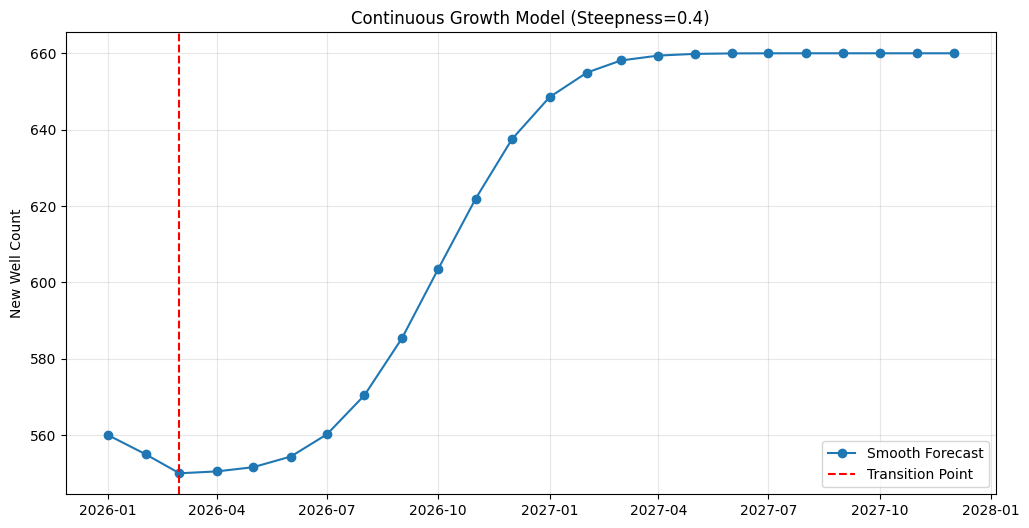

In [51]:
def objective_function(params, target_sum_remaining, num_fixed, last_fixed_val):
    t_mid, sigma = params
    effective_sigma = sigma / SLOPE_STEEPNESS

    months_total = np.arange(12)
    full_curve = s_curve_rate(months_total, t_mid, effective_sigma, S_CURVE_START_RATE, S_CURVE_FINAL_RATE)

    # 1. Match the value at the end of the fixed period (smooth connection)
    val_match = (full_curve[num_fixed-1] - last_fixed_val)

    # 2. Match the target sum for the rest of 2026
    sum_match = (np.sum(full_curve[num_fixed:]) - target_sum_remaining)

    # 3. Growth constraint: Ensure the rate in April is strictly greater than March
    # to prevent a 'flat' start. We add a small penalty if it's too close to the start rate.
    growth_penalty = 0
    if full_curve[num_fixed] <= last_fixed_val + 1:
        growth_penalty = (last_fixed_val + 5 - full_curve[num_fixed]) * 10

    return [sum_match, val_match * 100, growth_penalty]

# Optimization Setup
num_fixed = len(FIXED_RATES)
last_fixed_val = FIXED_RATES[-1]
target_remaining_2026 = TARGET_SUM_2026 - sum(FIXED_RATES)

# Adjust initial guess to encourage earlier growth (lower t_mid)
res = least_squares(objective_function, [4, 5], bounds=([-10, 0.1], [20, 30]),
                    args=(target_remaining_2026, num_fixed, last_fixed_val))

if res.success:
    optimized_t_mid, optimized_sigma = res.x
    effective_sigma = optimized_sigma / SLOPE_STEEPNESS

    total_months = 24
    months_idx = np.arange(total_months)
    full_s_curve = s_curve_rate(months_idx, optimized_t_mid, effective_sigma, S_CURVE_START_RATE, S_CURVE_FINAL_RATE)

    full_forecast = np.concatenate([FIXED_RATES, full_s_curve[num_fixed:]])

    date_index = pd.date_range(start=START_DATE, periods=total_months, freq='MS')
    df = pd.DataFrame({'Date': date_index, 'New_Wells': full_forecast})

    actual_2026_sum = df[df['Date'].dt.year == 2026]['New_Wells'].sum()
    print(f"\n--- Continuous Growth Verification ---")
    print(f"Total Wells in 2026: {actual_2026_sum:.2f} (Target: {TARGET_SUM_2026})")
    print(f"March (Fixed): {df['New_Wells'].iloc[2]:.2f}")
    print(f"April (Forecast): {df['New_Wells'].iloc[3]:.2f}")
    print(f"May (Forecast): {df['New_Wells'].iloc[4]:.2f}")

    plt.figure(figsize=(12, 6))
    plt.plot(df['Date'], df['New_Wells'], marker='o', label='Smooth Forecast')
    plt.axvline(df['Date'].iloc[num_fixed-1], color='r', linestyle='--', label='Transition Point')
    plt.title(f'Continuous Growth Model (Steepness={SLOPE_STEEPNESS})')
    plt.ylabel('New Well Count')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print(f'Optimization failed: {res.message}')

Optimizing S-curve parameters...
Optimization successful!
Optimized t_mid: 6.91 months, Optimized sigma: 3.07

--- Verification ---
Initial month's rate (Month 0): 501.81 wells/month (Target: 500)
Total wells for first 12 months: 6700.00 wells (Target: 7000)
Stabilized rate (Month 23): 650.00 wells/month (Target: ~650)


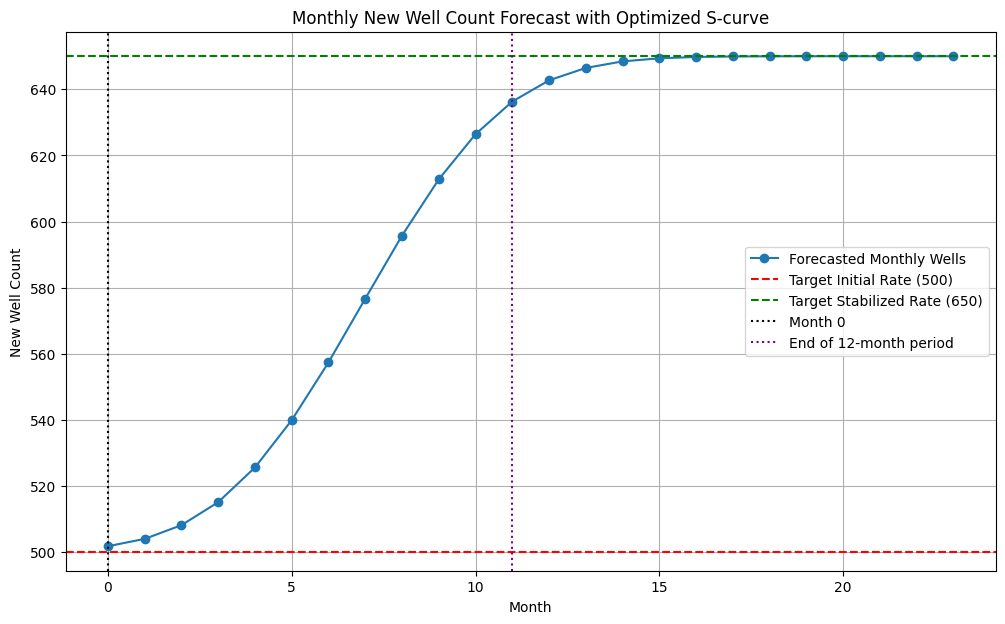

In [4]:
# Define the objective function for optimization
def objective_function(params, target_sum=6700, num_months=12):
    """
    Calculates the difference between the actual sum of wells over num_months
    and the target_sum. This function is minimized by least_squares.
    """
    t_mid, sigma = params

    # Generate time points for the 12 months (0 to 11)
    months = np.arange(num_months)

    # Calculate monthly well counts using the S-curve model
    monthly_counts = s_curve_rate(months, t_mid, sigma)

    # Sum the monthly counts
    current_sum = np.sum(monthly_counts)

    # Return the residual (difference from target_sum)
    return [current_sum - target_sum]

# Initial guess for the parameters (t_mid, sigma)
# t_mid: The midpoint of the S-curve (e.g., around month 6)
# sigma: Controls the steepness (e.g., 3 months for a reasonable spread)
initial_guess = [6, 3]

# Bounds for the parameters:
# t_mid: Can be negative (if growth starts before month 0) or positive.
# sigma: Must be positive.
bounds = ([-10, 0.1], [20, 10]) # t_mid: -10 to 20 months, sigma: 0.1 to 10

print("Optimizing S-curve parameters...")
# Perform the optimization using least_squares
# It minimizes the sum of squares of residuals, which is just (sum_diff)^2 in our case.
res = least_squares(objective_function, initial_guess, bounds=bounds)

# Extract optimized parameters
if res.success:
    optimized_t_mid, optimized_sigma = res.x
    print(f"Optimization successful!\nOptimized t_mid: {optimized_t_mid:.2f} months, Optimized sigma: {optimized_sigma:.2f}")

    # Generate forecast using the optimized parameters
    # Extend to 24 months to show stabilization for "next year"
    months_forecast = np.arange(24)
    monthly_wells_forecast = s_curve_rate(months_forecast, optimized_t_mid, optimized_sigma)

    # Verify conditions
    initial_month_rate = monthly_wells_forecast[0]
    sum_first_12_months = np.sum(monthly_wells_forecast[:12])
    stabilized_rate = monthly_wells_forecast[-1] # Rate at the end of the 2-year period (month 23)

    print(f"\n--- Verification ---")
    print(f"Initial month's rate (Month 0): {initial_month_rate:.2f} wells/month (Target: 500)")
    print(f"Total wells for first 12 months: {sum_first_12_months:.2f} wells (Target: 7000)")
    print(f"Stabilized rate (Month 23): {stabilized_rate:.2f} wells/month (Target: ~650)")

    # Plotting the forecast
    plt.figure(figsize=(12, 7))
    plt.plot(months_forecast, monthly_wells_forecast, marker='o', linestyle='-', label='Forecasted Monthly Wells')
    plt.axhline(y=500, color='r', linestyle='--', label='Target Initial Rate (500)')
    plt.axhline(y=650, color='g', linestyle='--', label='Target Stabilized Rate (650)')
    plt.axvline(x=0, color='k', linestyle=':', label='Month 0')
    plt.axvline(x=11, color='purple', linestyle=':', label='End of 12-month period')

    plt.title('Monthly New Well Count Forecast with Optimized S-curve')
    plt.xlabel('Month')
    plt.ylabel('New Well Count')
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print(f"Optimization failed: {res.message}")